# 🎓 机器学习全流程实战 (Challenge)

## 🎯 目标
不依赖 Copy & Paste，手写一个完整的机器学习 pipeline。
本次挑战包含两个任务：
1.  **回归任务 (Regression)**: 预测员工的工资 (`salary_amount`) —— 数值预测。
2.  **分类任务 (Classification)**: 预测员工是否会离职 (`left`) —— 类别预测。

## 📚 函数加油站 (Function Cheat Sheet)

| 步骤 | 核心函数 | SQL 类比 |
| :--- | :--- | :--- |
| **1. 概览** | `df.info()`, `df.describe()`, `df.corr()` | `DESC table`, `SELECT AVG()` |
| **2. 清洗** | `df.fillna(0)`, `df.dropna()` | `COALESCE(col, 0)`, `WHERE col IS NOT NULL` |
| **3. 独热编码** | `pd.get_dummies(df, columns=['col'])` | `CASE WHEN col='A' THEN 1 ELSE 0 END` |
| **4. 缩放** | `StandardScaler().fit_transform(df)` | `(x - avg) / std` (Z-Score) |
| **5. 切分** | `train_test_split(X, y, test_size=0.2)` | N/A (随机采样) |
| **6. 回归模型** | `xgb.XGBRegressor().fit(X, y)` | 拟合一条线/面 |
| **7. 分类模型** | `xgb.XGBClassifier().fit(X, y)` | 画一个圈/边界 |
| **8. 评估(Reg)**| `mean_squared_error(y_true, y_pred)` | 误差平方和 |
| **9. 评估(Cls)**| `roc_auc_score(y_true, y_prob)` | 排序能力 |

In [1]:
# 0. 导入工具包
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, roc_auc_score

# 忽略警告
import warnings
warnings.filterwarnings('ignore')

## 🧩 1. 数据准备 (Data Gen)
*这部分代码已为你写好，直接运行即可生成模拟数据。*

In [2]:
# 生成模拟 HR 数据
np.random.seed(42)
n_samples = 2000

# 特征
data = {
    'satisfaction': np.random.uniform(0.1, 1.0, n_samples),
    'evaluation': np.random.uniform(0.4, 1.0, n_samples),
    'project_count': np.random.randint(2, 7, n_samples),
    'wsh': np.random.randint(150, 310, n_samples),  # work_hours
    'tenure': np.random.randint(2, 10, n_samples),
    'dept': np.random.choice(['sales', 'tech', 'support', 'hr'], n_samples),
    'salary_level': np.random.choice(['low', 'medium', 'high'], n_samples)
}

df = pd.DataFrame(data)

# 构造目标变量 y (有些噪声)
# 1. 工资 (Regression Target): 由工龄、评估、职位等级决定
salary_map = {'low': 4000, 'medium': 8000, 'high': 15000}
base_salary = df['salary_level'].map(salary_map) + df['tenure'] * 500 + df['evaluation'] * 2000
df['salary_amount'] = base_salary + np.random.normal(0, 500, n_samples) # 加点噪声

# 2. 离职 (Classification Target): 满意度低 或 工时长且工资低 的人容易走
prob_leave = 0.1
prob_leave += np.where(df['satisfaction'] < 0.4, 0.5, 0)
prob_leave += np.where((df['wsh'] > 250) & (df['salary_level'] == 'low'), 0.3, 0)
df['left'] = np.random.binomial(1, np.clip(prob_leave, 0, 1))

print(f"数据生成完毕! 形状: {df.shape}")
df.head()

数据生成完毕! 形状: (2000, 9)


,satisfaction,evaluation,project_count,wsh,tenure,dept,salary_level,salary_amount,left
0,0.437086,0.557023,3,234,8,hr,low,9372.544725,0
1,0.955643,0.548187,6,198,7,tech,low,8162.852945,1
2,0.758795,0.943753,6,219,5,support,low,8050.593306,0
3,0.638793,0.549728,4,280,2,tech,low,6655.249096,1
4,0.240417,0.563170,5,282,6,hr,medium,12433.212818,1


---

## ⚔️ 挑战 1: 数据概览与清洗 (EDA & Cleaning)

**任务**:
1.  检查有没有缺失值 (虽然这里没有，但养成好习惯)。
2.  看看 `salary_amount` (数值) 的分布。
3.  看看 `left` (类别) 的比例。

In [3]:
# TODO: 你的代码
print(df.isnull().sum())
print(df.info())
# print(df.describe(include='all'))

satisfaction     0
evaluation       0
project_count    0
wsh              0
tenure           0
dept             0
salary_level     0
salary_amount    0
left             0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   satisfaction   2000 non-null   float64
 1   evaluation     2000 non-null   float64
 2   project_count  2000 non-null   int64  
 3   wsh            2000 non-null   int64  
 4   tenure         2000 non-null   int64  
 5   dept           2000 non-null   object 
 6   salary_level   2000 non-null   object 
 7   salary_amount  2000 non-null   float64
 8   left           2000 non-null   int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 140.8+ KB
None


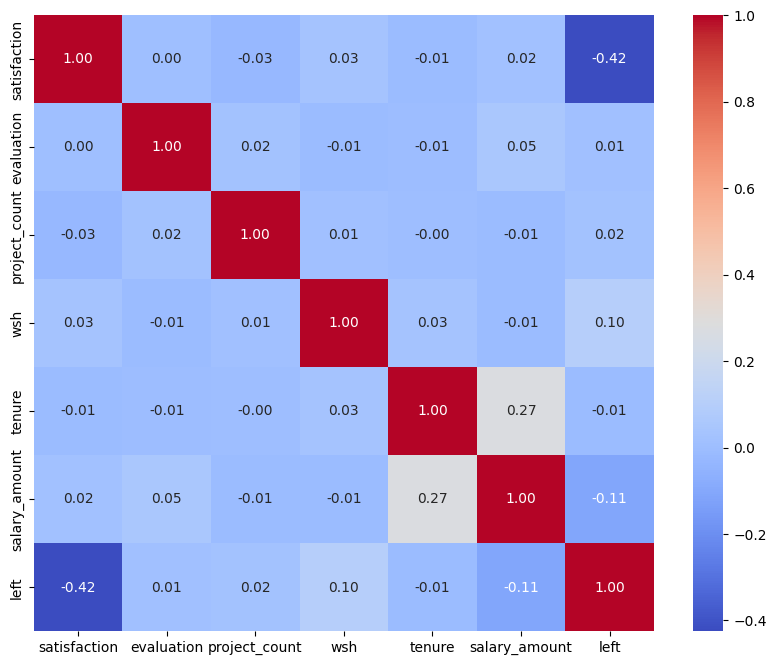

In [4]:
# 看下所有特征值之间的相关性
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()


In [5]:
# 筛选相关性高的指标 看看是否需要补充新的特征值
corr_matrix = df.corr(numeric_only=True)
corr_pairs = corr_matrix.unstack()
high_corr = corr_pairs[(abs(corr_pairs) > 0.7) & (abs(corr_pairs) < 1)]
high_corr = high_corr.drop_duplicates()
print(high_corr)
low_corr = corr_pairs[(abs(corr_pairs) < 0.7) & (abs(corr_pairs) > 0.1)]
low_corr = low_corr.drop_duplicates().sort_values(ascending=False)
print(low_corr)

Series([], dtype: float64)
tenure         salary_amount    0.271250
wsh            left             0.103151
salary_amount  left            -0.111805
satisfaction   left            -0.424699
dtype: float64


特征变量 (Features - X)
satisfaction: 员工满意度评分 (0.0 - 1.0，越高越满意)。
evaluation: 上一次绩效评估分数 (0.0 - 1.0，越高表现越好)。
project_count: 手头参与的项目数量。
wsh (Work Scedule Hours): 平均每月工作时长 (小时)。
tenure: 司龄 (在公司待了几年)。
dept: 所属部门 (Sales, Tech, Support, HR)。
salary_level: 工资档位 (Low, Medium, High) —— 这是目前 HR 系统里记录的粗略档位。
目标变量 (Targets - y)
salary_amount (回归目标): 实际的薪资数值。
场景: HR 想通过其他特征，精准估算一个员工的实际市场价值。
left (分类目标): 是否离职。
0: 在职 (Stay)
1: 离职 (Left)


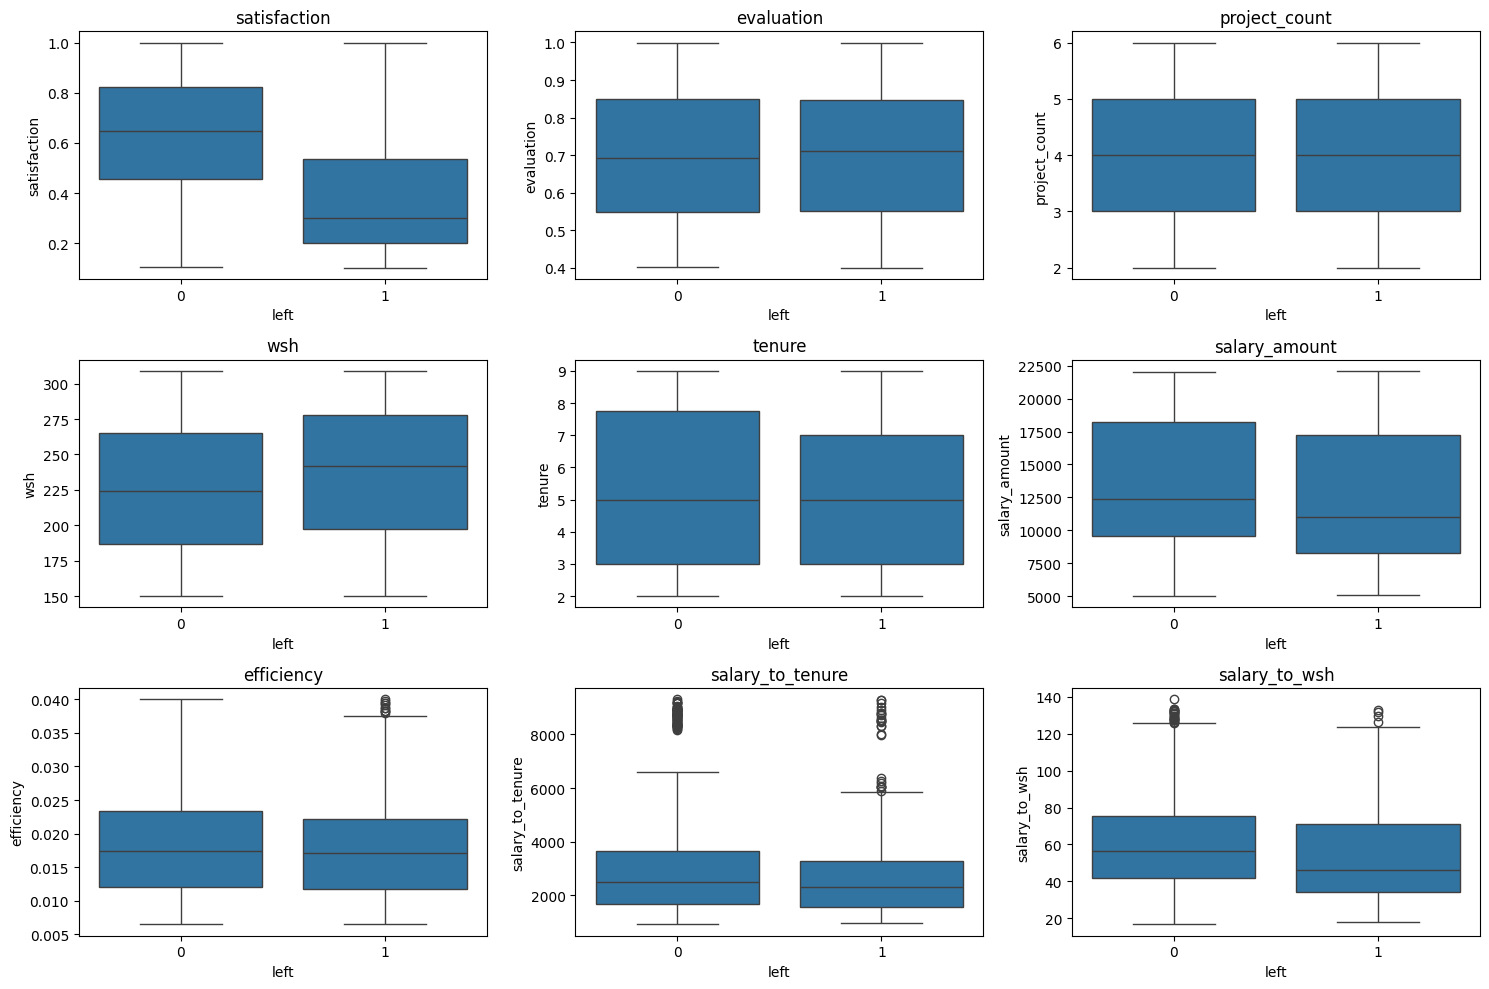

In [6]:
# 新增特征 工作效率 = 项目数量 / 平均每月工作时长
df['efficiency'] = df['project_count'] / df['wsh']
# 新增特征 薪资和工作年限的比例
df['salary_to_tenure'] = df['salary_amount'] / df['tenure']
# 薪资特征 薪资和平均每月工作时长的关系
df['salary_to_wsh'] = df['salary_amount'] / df['wsh']

num_cols = df.select_dtypes(include=['number']).columns.tolist()
if 'left' in num_cols:num_cols.remove('left')

plt.figure(figsize=(15,10))
for i,col in enumerate(num_cols):
    plt.subplot(3,3,i+1)
    sns.boxplot(data=df,x='left',y=col)
    plt.title(col)
plt.tight_layout()

---

## ⚔️ 挑战 2: 特征工程 (Feature Eng)

**任务**:
1.  **One-hot 编码**: 把 `dept` 和 `salary_level` 变成数字/哑变量 (dummy variables)。
    *   *提示*: `pd.get_dummies()`
2.  **定义 X 和 y**:
    *   `X`: 除了 `salary_amount` 和 `left` 之外的所有列。
    *   `y_reg`: `salary_amount` (回归目标)
    *   `y_cls`: `left` (分类目标)
3.  **切分数据**:
    *   只需要切分一次 X，因为 y 可以分批取。
    *   或者为了稳妥，分别切分 `X_train_r, X_test_r` (Reg) 和 `X_train_c, X_test_c` (Cls)。
    *   *建议*: 统一 `random_state=42`。

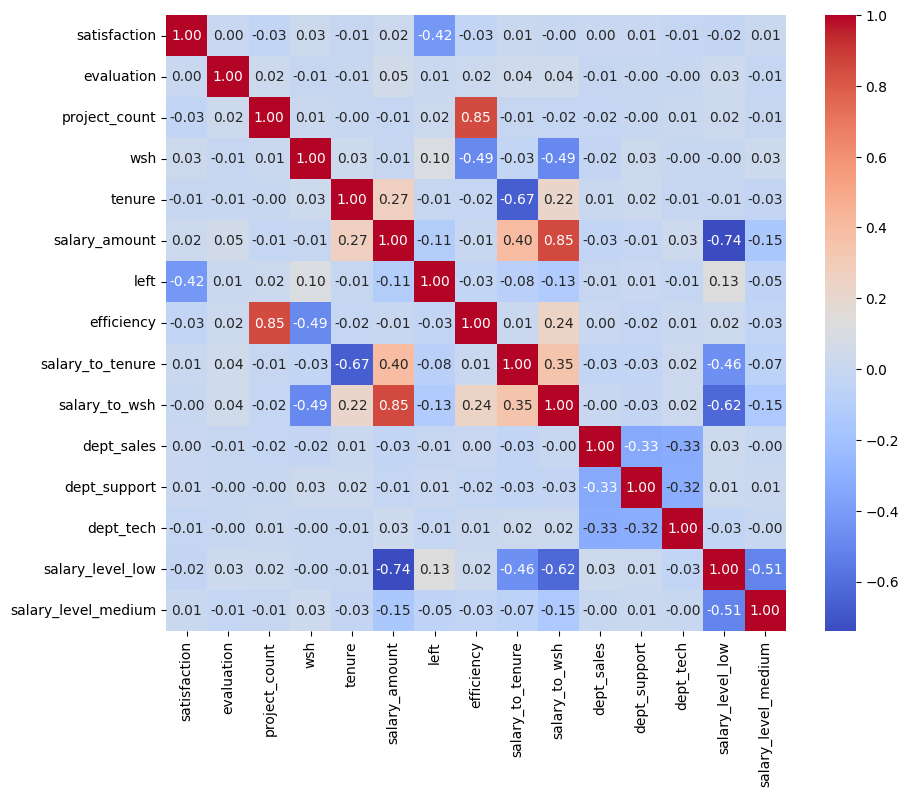

In [7]:
# TODO: One-hot Encoding

df_processed = pd.get_dummies(df,columns=['dept','salary_level'],drop_first=True)
# 看下所有特征值之间的相关性
plt.figure(figsize=(10, 8))
sns.heatmap(df_processed.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

In [8]:
# TODO: Define X, y_reg, y_cls
scaler = StandardScaler()
cols_to_scale = ['project_count', 'wsh', 'tenure',
       'salary_amount', 'efficiency', 'salary_to_tenure',
       'salary_to_wsh']
# 只改变选中的列
df_processed[cols_to_scale] = scaler.fit_transform(df_processed[cols_to_scale])

df_processed.describe().round(4)


,satisfaction,evaluation,project_count,wsh,tenure,salary_amount,left,efficiency,salary_to_tenure,salary_to_wsh
count,2000.0000,2000.0000,2000.0000,2000.0000,2000.0000,2000.0000,2000.0000,2000.0000,2000.0000,2000.0000
mean,0.5488,0.6978,0.0000,0.0000,-0.0000,0.0000,0.3170,0.0000,-0.0000,0.0000
std,0.2630,0.1731,1.0003,1.0003,1.0003,1.0003,0.4654,1.0003,1.0003,1.0003
min,0.1029,0.4000,-1.4314,-1.7504,-1.4658,-1.6989,0.0000,-1.5530,-1.1297,-1.6671
25%,0.3142,0.5505,-0.7203,-0.8748,-1.0341,-0.8412,0.0000,-0.8198,-0.7240,-0.7673
50%,0.5566,0.6956,-0.0092,0.0007,-0.1707,-0.2209,0.0000,-0.1113,-0.2861,-0.2410
75%,0.7756,0.8492,0.7018,0.8543,0.6926,1.0567,1.0000,0.6449,0.3525,0.5977
max,0.9997,0.9997,1.4129,1.7298,1.5560,1.9170,1.0000,2.8944,3.5986,3.1107


In [9]:
# 1. 准备好数据
x = df_processed.drop(columns=['salary_amount','left'])
y_reg = df_processed['salary_amount']
y_clf = df_processed['left']

# 2. 一次性切分 (One-time split)
# python会自动解包返回的6个部分
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    x, y_reg, y_clf, 
    test_size=0.2, 
    random_state=42
)

# 3. 验证形状
print("X 训练集:", X_train.shape)
print("y_reg 训练集:", y_reg_train.shape) # 行数应该和 X_train 一致
print("y_clf 训练集:", y_clf_train.shape) # 行数也应该和 X_train 一致

X 训练集: (1600, 13)
y_reg 训练集: (1600,)
y_clf 训练集: (1600,)


---

## ⚔️ 挑战 3: 回归实战 (Regression)

**目标**: 预测员工工资 (`salary_amount`)。

**任务**:
1.  实例化 `XGBRegressor`。
2.  训练模型 (`fit`)。
3.  预测测试集 (`predict`)。
4.  评估误差 (`mean_absolute_error`): 平均预测错了多少钱？

In [10]:
# TODO: Regressor 建模与评估
xgb_reg = xgb.XGBRegressor(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=5, 
    random_state=42
)
xgb_reg.fit(X_train,y_reg_train)

y_pred_r = xgb_reg.predict(X_test)

# 5. 评估 (回归看误差)
mse = mean_squared_error(y_reg_test, y_pred_r)
mae = mean_absolute_error(y_reg_test, y_pred_r)

print(f"均方误差 (MSE): {mse:.4f} (越小越好)")
print(f"平均绝对误差 (M[目标业务]): {mae:.4f}")

# 看看真实 vs 预测
print(f"\n真实满意度 (前5个): {y_reg_test[:5].values}")
print(f"预测满意度 (前5个): {y_pred_r[:5]}")

均方误差 (MSE): 0.0084 (越小越好)
平均绝对误差 (M[目标业务]): 0.0586

真实满意度 (前5个): [-0.59637517 -0.95068982  0.13991162  1.42274458 -0.36186591]
预测满意度 (前5个): [-0.60181063 -0.92196214 -0.08562456  1.369197   -0.26489887]


---

## ⚔️ 挑战 4: 分类实战 (Classification)

**目标**: 预测员工是否离职 (`left`)。

**任务**:
1.  实例化 `XGBClassifier`。
2.  训练模型 (`fit`)。
3.  预测概率 (`predict_proba`) —— *注意我们要算 AUC，所以要概率，不是类别 0/1*。
4.  评估指标 (`roc_auc_score`): 看看 AUC 能到多少？

In [13]:
# TODO: Classifier 建模与评估
xgb_cla = xgb.XGBClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=5, 
    eval_metric='logloss',
    random_state=42
)

xgb_cla.fit(X_train,y_clf_train)
y_pred_c = xgb_cla.predict(X_test)
y_prod_c = xgb_cla.predict_proba(X_test)[:, 1]

# 计算 XGBoost 的指标
acc_xgb = accuracy_score(y_clf_test, y_pred_c)
auc_xgb = roc_auc_score(y_clf_test, y_prod_c)

print(f"🚀 XGBoost  Accuracy: {acc_xgb:.4f}, AUC: {auc_xgb:.4f}")


🚀 XGBoost  Accuracy: 0.7625, AUC: 0.7746


---

## 💡 参考答案 (Solution)
*试着先自己写，实在卡住了再点开看。*

In [12]:
# EDA
print("Missing:", df.isnull().sum().sum())
print("Salary Mean:", df['salary_amount'].mean())
print("Left Rate:", df['left'].mean())

# Feature Eng
df_encoded = pd.get_dummies(df, columns=['dept', 'salary_level'], drop_first=True)
X = df_encoded.drop(['salary_amount', 'left'], axis=1)
y_reg = df_encoded['salary_amount']
y_cls = df_encoded['left']

# Split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y_reg, test_size=0.2, random_state=42)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_cls, test_size=0.2, random_state=42)

# Regression
reg = xgb.XGBRegressor(n_estimators=100, random_state=42)
reg.fit(X_train_r, y_train_r)
y_pred_r = reg.predict(X_test_r)
print(f"M[目标业务] (Salary Error): {mean_absolute_error(y_test_r, y_pred_r):.2f}")

# Classification
cls = xgb.XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')
cls.fit(X_train_c, y_train_c)
y_prob_c = cls.predict_proba(X_test_c)[:, 1]
print(f"AUC (Churn Prediction): {roc_auc_score(y_test_c, y_prob_c):.4f}")

Missing: 0
Salary Mean: 13037.612313656606
Left Rate: 0.317
M[目标业务] (Salary Error): 242.65
AUC (Churn Prediction): 0.7615


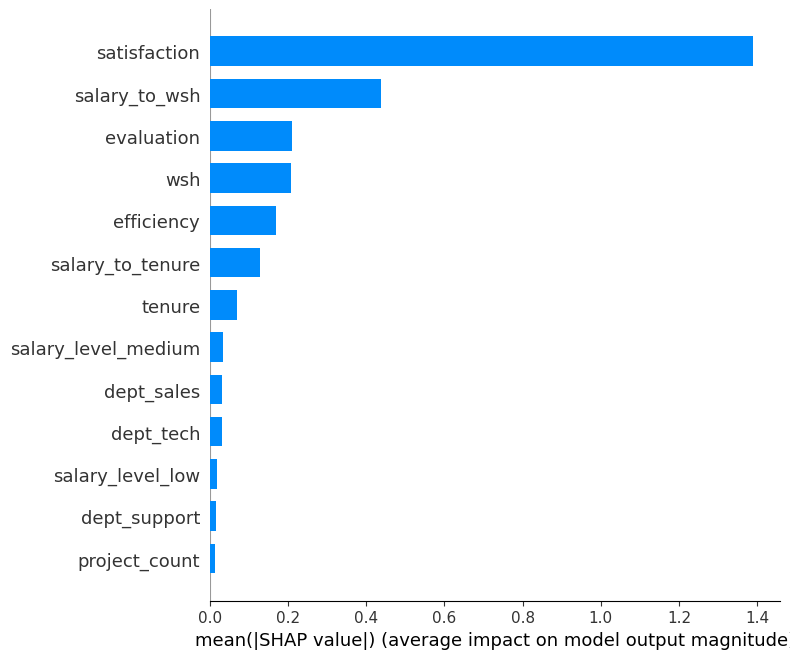

😱 发现 29 名【高绩效-高风险】员工，必须马上干预！


,satisfaction,evaluation,project_count,wsh,tenure,efficiency,salary_to_tenure,salary_to_wsh,dept_sales,dept_support,dept_tech,salary_level_low,salary_level_medium,proba_leave,performance
353,0.246641,0.924219,1.412873,-1.268837,0.260956,2.215770,-0.845776,-0.372600,False,False,True,True,False,0.763118,0.924219
938,0.205976,0.971333,-1.431361,-0.502750,-0.170733,-1.129933,-0.703232,-0.731066,True,False,False,True,False,0.769669,0.971333
374,0.164070,0.803780,-0.009244,1.379635,0.260956,-0.600651,-0.854310,-1.186944,True,False,False,True,False,0.953813,0.803780
128,0.106257,0.929157,-1.431361,-0.261980,0.692646,-1.194603,-0.002282,1.353012,False,False,True,False,False,0.700988,0.929157
964,0.359824,0.913922,0.701815,-1.334501,0.692646,1.512997,-0.555105,0.827111,False,True,False,False,True,0.703815,0.913922


In [14]:
# 1. 安装 SHAP (如果还没装)
# !pip install shap

# 2. SHAP 解释 (Why did they leave?)
import shap
explainer = shap.TreeExplainer(xgb_cla)
shap_values = explainer.shap_values(X_test)

# Summary Pilot (全局重要性)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar")
plt.show()

# 3. 挽留优先级矩阵 (Retention Matrix)
# 找出 "高价值" (performance > 0.8) 且 "高风险" (prob > 0.7) 的人
results = X_test.copy()
results['proba_leave'] = y_prod_c
results['performance'] = df.loc[X_test.index, 'evaluation'] # 找回原始绩效

# 定义 "必救名单"
must_save = results[
    (results['proba_leave'] > 0.7) & 
    (results['performance'] > 0.8)
]

print(f"😱 发现 {len(must_save)} 名【高绩效-高风险】员工，必须马上干预！")
must_save.head()

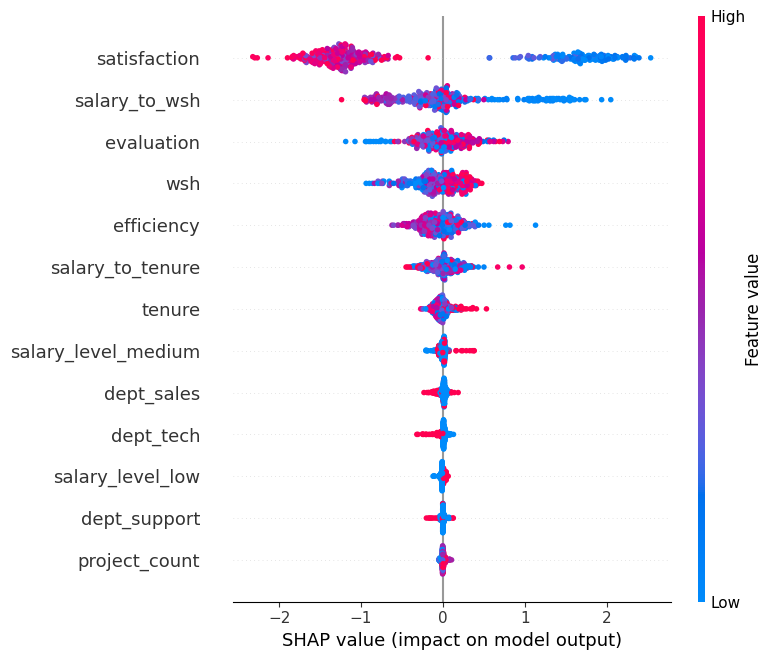

In [15]:
# 蜂群图 (Beeswarm Plot) - 默认样式
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test) 
plt.show()